# 📗 기초 수학 종합 과제
## Private LLM 사내 문서 검색·압축·Attention 진단

여러분은 사내 지식 검색 Private LLM의 **PoC 검증 담당 AI 엔지니어**입니다. 서비스 오픈 전 아래 항목을 코드와 실행 결과로 확인해야 합니다.

1. 질문과 관련된 문서가 Vector Search 상위에 노출되는지 확인합니다.
2. 정보 보존율 90% 이상을 유지하면서 임베딩 차원과 저장량을 줄일 수 있는지 판단합니다.
3. Causal Attention에서 미래 토큰 누수가 없는지 진단합니다.
4. Gradient 계산과 한 번의 SGD 업데이트가 Loss를 실제로 줄이는지 확인합니다.

```text
문서 특징 → Projection → Cosine Search
         → PCA/SVD 압축
         → Causal Attention → Cross Entropy
         → Autograd → Gradient Descent
```

- 외부 데이터 다운로드, 유료 API, GPU를 사용하지 않습니다.
- 위에서 아래로 순서대로 실행하세요.
- 공식 구현 성취도는 문제 1~3의 15점이며, 문제 4는 별도 추가 종합 평가 5점입니다.
- 선택 심화 M1~M4는 점수 필수 조건이 아닙니다.
- 각 문제의 TODO를 완성한 뒤 자동 검증 셀에서 `PASS`를 확인하세요.
- 마지막에는 실행 결과를 근거로 **엔지니어링 요약 보고서**를 작성하세요.


## 0. 실행 환경·제출·채점 안내

- 권장 환경: Google Colab 무료 CPU 런타임
- 핵심 dtype: `float64`
- **공식 구현 성취도:** 문제 1-3을 각각 1-5점으로 평가하여 총 15점입니다.
- **추가 종합 평가:** 문제 4를 0~5점으로 별도 평가합니다.
- **전체 합계:** 20점입니다.
- 선택 심화 M1~M4는 5점을 받기 위한 필수 조건이 아니며 점수에 직접 반영하지 않습니다.
- 선택 심화를 수행하지 않을 때는 `RUN_M*_CHALLENGE = False`로 유지하세요.
- 문제 4는 **Checkpoint A → B → C** 순서로 진행하세요.
- 제출 전 `런타임 → 세션 다시 시작 → 모두 실행`을 수행하세요.

### 공식 구현 성취도 매핑

| 문제 | 공식 구현 평가 항목 | 배점 |
|---|---|---:|
| 문제 1 | 벡터 ⋅ 행렬 연산을 Numpy로 구현하고 결과를 검증할 수 있다 | 5점 |
| 문제 2 | 고유값 분해를 통해 PCA를 구현하고, 주성분 개수에 따른 분산 설명력 변화를 분석하여 적절한 차원 수를 결정할 수 있다 | 5점 |
| 문제 3 | SVD를 구현하여 행렬을 저차원으로 근사하고, 압축률과 정보 손실 간의 관계를 비교·해석할 수 있다 | 5점 |
| 문제 4 | Attention·Cross Entropy·Gradient를 연결하는 추가 종합 평가 | 5점 |

### 필수 산출물

1. 공식 성취도 문제 1~3 자동 검증 `PASS`
2. 추가 종합 문제 4 Checkpoint A·B·C `PASS`
3. 표와 그래프가 포함된 실행 결과
4. PCA·SVD 의사결정 메모
5. Attention 누수·위치별 NLL·업데이트 전후 Loss 진단
6. 마지막의 최종 엔지니어링 요약 보고서


In [1]:
import sys
import platform
import hashlib

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import torch
import torch.nn.functional as F

# 나눔고딕 폰트 설치
!apt-get -qq install fonts-nanum > /dev/null

import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rc("font", family="NanumGothic")
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

np.set_printoptions(precision=6, suppress=True)
torch.set_printoptions(precision=6)


def result_signature(values, decimals=10):
    """자동 검증용 숫자 배열 서명을 만듭니다. 정답 숫자를 직접 노출하지 않습니다."""
    array = np.asarray(values, dtype=np.float64)
    rounded = np.round(array, decimals=decimals)
    return hashlib.sha256(rounded.tobytes()).hexdigest()


def text_signature(values):
    """문자열 목록의 순서까지 포함한 자동 검증용 서명을 만듭니다."""
    text = "|".join(map(str, values))
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("PyTorch:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())


Python: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
NumPy: 2.1.3
pandas: 2.2.3
Matplotlib: 3.10.0
scikit-learn: 1.6.1
PyTorch: 2.11.0+cpu
CUDA 사용 가능: False


## 0-1. 제공 데이터

`document_features`는 실제 기업 데이터가 아니라 학습을 위해 직접 구성한 고정 숫자입니다. 각 열은 보안, 인사, 인프라, 비용, 절차, 정책, 문제 해결, 계정 요청 신호를 나타냅니다.

한 문서 벡터의 크기를 의도적으로 크게 설정해, 정규화하지 않은 내적과 Cosine Similarity의 차이를 관찰할 수 있도록 했습니다.


In [2]:
document_titles = [
    "VPN 접속 오류 해결",
    "비밀번호 재설정 절차",
    "계정 잠금 해제 가이드",
    "연차 신청 방법",
    "복리후생 제도 안내",
    "재택근무 보안 정책",
    "GCP GPU VM 생성",
    "Kubernetes 배포 체크리스트",
    "서비스 장애 대응 절차",
    "법인카드 정산 규정",
    "출장비 지급 기준",
    "구매 요청 승인 절차",
]

feature_names = [
    "보안·접근",
    "인사",
    "인프라",
    "비용",
    "절차",
    "정책",
    "문제해결",
    "계정·요청",
]

document_features = np.array([
    [0.80, 0.00, 0.60, 0.00, 0.70, 0.20, 0.90, 0.50],
    [1.00, 0.00, 0.10, 0.00, 1.00, 0.40, 0.70, 0.90],
    [0.95, 0.00, 0.05, 0.00, 0.90, 0.30, 0.85, 1.00],
    [0.10, 1.00, 0.00, 0.00, 0.90, 0.30, 0.10, 0.70],
    [0.00, 1.00, 0.00, 0.10, 0.50, 0.80, 0.00, 0.20],
    [0.70, 0.70, 0.20, 0.00, 0.40, 1.00, 0.20, 0.30],
    [0.10, 0.00, 1.00, 0.00, 0.80, 0.20, 0.50, 0.40],
    # 크기가 큰 문서 벡터: 정규화하지 않은 내적이 norm의 영향을 받는 사례입니다.
    [0.40, 0.00, 2.00, 0.00, 1.80, 0.80, 0.80, 0.40],
    [0.50, 0.00, 0.80, 0.00, 0.70, 0.30, 1.00, 0.20],
    [0.00, 0.10, 0.00, 1.00, 0.60, 0.90, 0.10, 0.30],
    [0.00, 0.30, 0.00, 1.00, 0.50, 0.80, 0.00, 0.20],
    [0.10, 0.20, 0.10, 0.80, 0.90, 0.70, 0.10, 0.80],
], dtype=np.float64)

projection_matrix = np.array([
    [0.8, 0.0, 0.1, 0.0, 0.2, 0.2],
    [0.0, 0.9, 0.0, 0.0, 0.1, 0.3],
    [0.1, 0.0, 0.9, 0.0, 0.2, 0.1],
    [0.0, 0.0, 0.0, 0.9, 0.1, 0.2],
    [0.2, 0.1, 0.1, 0.1, 0.7, 0.2],
    [0.2, 0.2, 0.1, 0.2, 0.1, 0.8],
    [0.3, 0.0, 0.3, 0.0, 0.8, 0.1],
    [0.5, 0.1, 0.1, 0.2, 0.3, 0.2],
], dtype=np.float64)

projection_bias = np.array([0.05, 0.02, 0.03, 0.01, 0.04, 0.02], dtype=np.float64)

query_text = "비밀번호를 잊었을 때 계정을 다시 사용하는 방법"
query_features = np.array([1.00, 0.00, 0.00, 0.00, 1.00, 0.20, 0.80, 0.95], dtype=np.float64)

print("문서 특징 Shape:", document_features.shape)
print("Projection 행렬 Shape:", projection_matrix.shape)
print("Bias Shape:", projection_bias.shape)
print("Query 특징 Shape:", query_features.shape)


문서 특징 Shape: (12, 8)
Projection 행렬 Shape: (8, 6)
Bias Shape: (6,)
Query 특징 Shape: (8,)


# 문제 1. 사내 문서 임베딩과 Cosine Vector Search — 공식 구현 성취도 5점

> **공식 구현 평가 항목:** 벡터 ⋅ 행렬 연산을 Numpy로 구현하고 결과를 검증할 수 있다.

## 채점 기준

| 점수 | 기준 |
|---:|---|
| 5점 | 정확한 구현과 결과 검증 + 브로드캐스팅/차원 처리와 수식 대응 근거까지 제시 |
| 4점 | 요구된 벡터·행렬 연산을 구현하고 결과를 검증 |
| 3점 | 연산은 되나 일부 검증 누락 또는 차원 처리 부정확 |
| 2점 | Shape 불일치 등 연산 오류로 결과가 잘못됨 |
| 1점 | 핵심 연산 구현이 되지 않아 실행 불가 |

## 실무 배경

사용자가 “비밀번호를 잊었을 때 계정을 다시 사용하는 방법”을 질문했습니다. 문서 특징을 작은 임베딩 공간으로 Projection한 뒤, Query와 가까운 문서를 Cosine Similarity로 검색하세요.

## 필수 구현

1. `(12, 8) @ (8, 6) + (6,)`으로 문서 임베딩 `(12, 6)`을 만드세요.
2. 같은 Projection을 Query `(8,)`에 적용해 Query 임베딩 `(6,)`을 만드세요.
3. 첫 문서·첫 출력 원소를 개별 내적으로 다시 계산해 행렬곱과 비교하세요.
4. 문서의 **각 행**과 Query를 각각 L2 정규화하세요.
5. 정규화된 내적으로 Cosine Similarity 12개를 계산하세요.
6. 점수가 큰 순서대로 Top-3 index·제목·점수를 `top3_table`로 정리하세요.

> 막혔다면 `axis=1`, `keepdims=True`, `np.argsort(...)[::-1]`을 먼저 확인하세요.

## 제출 결과

- 문서·Query 임베딩 Shape
- 정규화 전후 norm
- Cosine Top-3 표
- `문제 1 자동 검증: PASS`
- 브로드캐스팅·차원 처리·수식 대응 근거
- 검색 결과가 질문 의도와 맞는지에 대한 엔지니어링 해석


In [3]:
def l2_normalize_rows(matrix, eps=1e-12):
    """행별 L2 norm을 1로 맞추는 함수를 완성하세요."""
    # TODO: axis=1, keepdims=True를 사용하세요.
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix / (norms + eps)


def l2_normalize_vector(vector, eps=1e-12):
    """1차원 벡터의 L2 norm을 1로 맞추는 함수를 완성하세요."""
    # TODO
    norm = np.linalg.norm(vector)
    return vector / (norm + eps)


document_embeddings =  document_features @ projection_matrix + projection_bias   # TODO: document_features @ projection_matrix + projection_bias
query_embedding = query_features @ projection_matrix + projection_bias   # TODO: query_features에 같은 Projection 적용
first_component_by_dot = (
    np.dot(document_features[0,:], projection_matrix[:, 0])
    + projection_bias[0]
) # TODO: 첫 문서·첫 출력 차원의 개별 내적 + bias


normalized_documents = l2_normalize_rows(document_embeddings) # TODO
normalized_query = l2_normalize_vector(query_embedding)       # TODO
cosine_scores = normalized_documents @ normalized_query       # TODO
top3_indices = np.argsort(cosine_scores)[::-1][:3]            # TODO
top3_titles = [document_titles[i] for i in top3_indices]      # TODO
top3_table = pd.DataFrame({
    "rank": [1, 2, 3],
    "index": top3_indices,
    "title": top3_titles,
    "cosine_similarity": cosine_scores[top3_indices],
    "embedding_norm_before": np.linalg.norm(document_embeddings[top3_indices], axis=1),
})              # TODO: DataFrame으로 rank/index/title/score 정리

print(top3_table)


   rank  index         title  cosine_similarity  embedding_norm_before
0     1      2  계정 잠금 해제 가이드           0.999528               2.876704
1     2      1   비밀번호 재설정 절차           0.998024               2.871498
2     3      0  VPN 접속 오류 해결           0.975510               2.594186


In [4]:
problem_1_values = {
    "document_embeddings": document_embeddings,
    "query_embedding": query_embedding,
    "first_component_by_dot": first_component_by_dot,
    "normalized_documents": normalized_documents,
    "normalized_query": normalized_query,
    "cosine_scores": cosine_scores,
    "top3_indices": top3_indices,
    "top3_titles": top3_titles,
    "top3_table": top3_table,
}

missing_problem_1 = [name for name, value in problem_1_values.items() if value is None]

if missing_problem_1:
    print("문제 1 미완성:", missing_problem_1)
else:
    assert document_embeddings.shape == (12, 6), "문서 Projection Shape을 확인하세요."
    assert query_embedding.shape == (6,), "Query Projection Shape을 확인하세요."
    assert np.allclose(document_embeddings[0, 0], first_component_by_dot), "개별 내적 검증이 다릅니다."
    assert np.allclose(np.linalg.norm(normalized_documents, axis=1), 1.0), "문서의 행별 L2 정규화를 확인하세요."
    assert np.allclose(np.linalg.norm(normalized_query), 1.0), "Query L2 정규화를 확인하세요."
    assert cosine_scores.shape == (12,), "Cosine Score Shape을 확인하세요."
    assert np.all((-1.0 - 1e-12 <= cosine_scores) & (cosine_scores <= 1.0 + 1e-12)), "Cosine 범위를 확인하세요."
    assert list(top3_table.columns) == ["rank", "index", "title", "cosine_similarity", "embedding_norm_before"], "Top-3 표의 열을 확인하세요."
    assert result_signature(cosine_scores) == "36925b6756f42cb3cefa14061a30dd470d9b5b192ab12c3eccefb15b4013f21c", "Projection·정규화·Cosine 계산 순서를 확인하세요."
    assert result_signature(top3_indices) == "89cc6d9f671bcf9533fdf2720bc94179d00cf2f300639b976376bbb533abfb5e", "Top-3 정렬 순서를 확인하세요."
    assert text_signature(top3_titles) == "cfe4b5ad23a94ace112c6d30ebeaa1da495199e784bc69677ee68352fa2180c2", "Top-3 제목과 index 연결을 확인하세요."
    print("문제 1 자동 검증: PASS")


문제 1 자동 검증: PASS


### 문제 1 — 문서 검색 진단 보고

1. Bias Broadcasting의 Shape 근거:
document_features @ projection_matrix의 결과는 (12, 6)이고, 여기에 더해지는 projection_bias는 (6,)이다. numpy는 (6,)를 (1, 6)으로 취급한 뒤 행 방향으로 12번 복제하여 (12, 6)으로 broadcasting 한다. 그 결과 12개 문서 모두가 동일한 bias 6개 값을 공유한다.

2. 내적과 Cosine Similarity의 norm 영향 차이:
정규화하지 않은 raw dot product는 벡터의 크기(norm)에 비례해서 값이 커진다.반면 Cosine Similarity는 내적 전에 각 벡터를 L2 정규화하기 때문에 크기 정보는 사라지고 방향(의미적 유사성)만 비교하게 된다.

3. 실제 Cosine Top-3:
계정 잠금 해제 가이드(0.999528), 비밀번호 재설정 절차(0.998024), VPN 접속 오류 해결(0.975510)

4. Top-3가 질문 의도와 일치하는지:
query_features의 np.array 값을 보면 보안/접근(1.00), 절차(1.00), 문제해결(0.8), 계정/요청(0.95)에 특징이 집중되어 있고 Top-3로 뽑힌 세 문서 모두 보안·접근, 절차, 계정·요청 성격이 강한 문서들이다. 따라서 검색 결과는 쿼리의 의미와 정확히 일치한다.

5. 운영팀에 전달할 결론:
비밀번호·계정 관련 질문 시, Cosine 검색이 관련 매뉴얼 3건을 정확히 상위에 노출시켰고 문서 크기에 의한 왜곡도 없었다. 이 방식은 사내 헬프데스크 챗봇이나 FAQ 자동 추천 기능의 1차 검색 엔진으로 활용 가능하다.


## 🚀 문제 1 선택 심화 M1 — 공식 점수에 영향 없음

정규화하지 않은 내적 Top-3와 Cosine Top-3를 비교하세요. 큰 norm을 가진 문서가 내적 순위에서 과도하게 높아지는지 확인하세요.

In [5]:
RUN_M1_CHALLENGE = False

if RUN_M1_CHALLENGE:
    dot_scores = None         # TODO: 정규화 전 문서 임베딩과 Query 임베딩의 내적
    dot_top3_indices = None   # TODO: 내적 점수 Top-3 index
    comparison = None         # TODO: 내적 Top-3와 Cosine Top-3 비교표

    challenge_values = {
        "dot_scores": dot_scores,
        "dot_top3_indices": dot_top3_indices,
        "comparison": comparison,
    }
    missing = [name for name, value in challenge_values.items() if value is None]
    if missing:
        print("M1 미완성:", missing)
    else:
        assert result_signature(dot_scores) == "ea4e73d599dac67381e679c039926526e4b6a0bf2e7890106e12faf1c6866a19", "정규화 전 내적 점수를 확인하세요."
        assert result_signature(dot_top3_indices) == "8433572615f92080f68966fa06a7952f769d1a427cfc903728c40d6a4012ddf4", "내적 Top-3 정렬을 확인하세요."
        display(comparison)
        print("M1 도전 검증: PASS")
else:
    print("M1 도전: SKIPPED")


M1 도전: SKIPPED


# 문제 2. 고유값 분해 기반 PCA — 공식 구현 성취도 5점

> **공식 구현 평가 항목:** 고유값 분해를 통해 PCA를 구현하고, 주성분 개수에 따른 분산 설명력 변화를 분석하여 적절한 차원 수를 결정할 수 있다.

## 채점 기준

| 점수 | 기준 |
|---:|---|
| 5점 | PCA 정확한 구현 + 분산 설명력 기반 차원 결정 + 시각화·누적 기여율 근거·트레이드오프 해석 |
| 4점 | 고유값 분해 기반 PCA 구현과 분산 설명력 기반 차원 결정 완료 |
| 3점 | PCA는 구현했으나 분산 설명력 분석 또는 차원 결정 근거 부족 |
| 2점 | 분해·투영 오류로 주성분 결과가 잘못됨 |
| 1점 | PCA 구현이 되지 않음 |

## 실무 배경

문서 임베딩은 저장·시각화 비용이 커질 수 있습니다. 서비스팀은 **누적 설명분산 90% 이상을 유지하면서 차원을 최소화**하려고 합니다. 평균 중심화부터 고유값 분해, 투영·복원까지 직접 연결한 뒤 추천 차원을 보고하세요.

## 필수 구현

1. 열별 평균을 빼 평균 중심화하세요.
2. `np.cov(centered_embeddings, rowvar=False, ddof=1)`로 `(6, 6)` 표본 공분산을 계산하세요.
3. 대칭행렬용 `np.linalg.eigh`를 사용하세요.
4. 고유값과 대응 고유벡터를 **함께** 내림차순 정렬하세요.
5. 설명분산비와 누적 설명분산을 계산하세요.
6. 90% 이상을 처음 만족하는 최소 `k_90`을 구하세요.
7. 상위 주성분으로 투영하고 평균을 다시 더해 원래 6차원으로 복원하세요.
8. 재구성 MSE, 설명분산 표, 누적 설명분산 그래프, PC1·PC2 산점도를 남기세요.

> 고유벡터는 열 방향입니다. 정렬할 때 `eigenvectors[:, order]`처럼 열 순서를 함께 바꾸세요.


문제 2 TODO를 완성한 뒤 표와 그래프를 출력하세요.
  component  eigenvalue  explained_ratio  cumulative_ratio
0       PC1    0.945216         0.681743          0.681743
1       PC2    0.167268         0.120643          0.802387
2       PC3    0.145836         0.105185          0.907571
3       PC4    0.110238         0.079510          0.987082
4       PC5    0.016783         0.012105          0.999186
5       PC6    0.001128         0.000814          1.000000


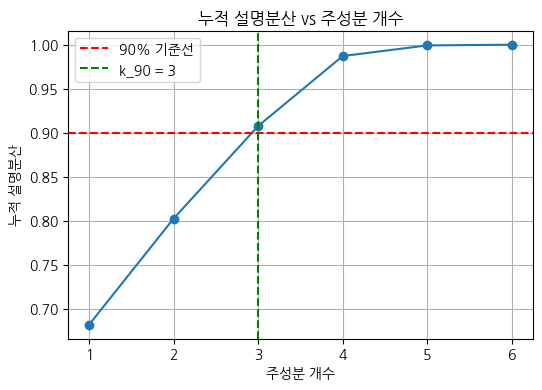

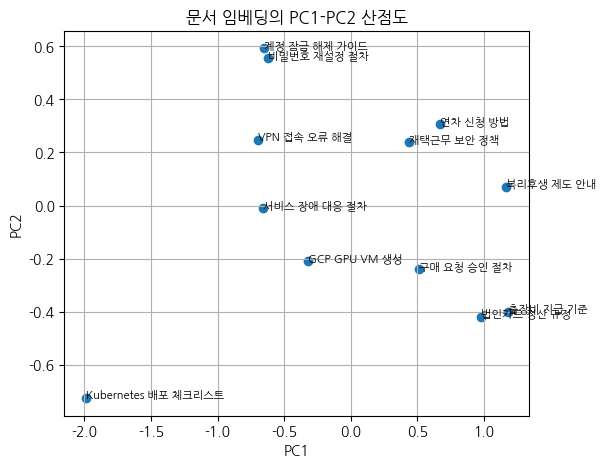

In [6]:
embedding_mean = np.mean(document_embeddings, axis=0, keepdims=True)          # TODO
centered_embeddings = document_embeddings - embedding_mean     # TODO
covariance = np.cov(centered_embeddings, rowvar=False, ddof=1)              # TODO

eigenvalues, eigenvectors = np.linalg.eigh(covariance)             # TODO         # TODO
order = np.argsort(eigenvalues)[::-1]      # 큰 값부터 오는 index 순서
eigenvalues = eigenvalues[order]            # 1차원이라 그냥 그 순서로 재배열
eigenvectors = eigenvectors[:, order]       # 열(각 고유벡터)을 그 순서로 재배열

explained_ratio = explained_ratio = eigenvalues / eigenvalues.sum()         # TODO
cumulative_ratio = np.cumsum(explained_ratio)        # TODO #모르던것(설명분산비, 누적 설명분산)
k_90_index = np.argmax(cumulative_ratio >= 0.90)
k_90 = k_90_index + 1                    # TODO
components = components = eigenvectors[:, :k_90]              # TODO
projected_embeddings = centered_embeddings @ components    # TODO
reconstructed_pca = projected_embeddings @ components.T + embedding_mean       # TODO
pca_reconstruction_mse = np.mean((document_embeddings - reconstructed_pca) ** 2)  # TODO
pca_table = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(eigenvalues))],
    "eigenvalue": eigenvalues,
    "explained_ratio": explained_ratio,
    "cumulative_ratio": cumulative_ratio,
})               # TODO

if document_embeddings is None:
    print("문제 1을 먼저 완성하세요.")
else:
    print("문제 2 TODO를 완성한 뒤 표와 그래프를 출력하세요.")

print(pca_table)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 7), cumulative_ratio, marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90% 기준선")
plt.axvline(k_90, color="green", linestyle="--", label=f"k_90 = {k_90}")
plt.xlabel("주성분 개수")
plt.ylabel("누적 설명분산")
plt.title("누적 설명분산 vs 주성분 개수")
plt.legend()
plt.grid(True)
plt.show()

pc1_pc2 = centered_embeddings @ eigenvectors[:, :2]   # (12, 2)

plt.figure(figsize=(6, 5))
plt.scatter(pc1_pc2[:, 0], pc1_pc2[:, 1])
for i, title in enumerate(document_titles):
    plt.annotate(title, (pc1_pc2[i, 0], pc1_pc2[i, 1]), fontsize=8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("문서 임베딩의 PC1-PC2 산점도")
plt.grid(True)
plt.show()

In [7]:
problem_2_values = {
    "embedding_mean": embedding_mean,
    "centered_embeddings": centered_embeddings,
    "covariance": covariance,
    "eigenvalues": eigenvalues,
    "eigenvectors": eigenvectors,
    "explained_ratio": explained_ratio,
    "cumulative_ratio": cumulative_ratio,
    "k_90": k_90,
    "components": components,
    "projected_embeddings": projected_embeddings,
    "reconstructed_pca": reconstructed_pca,
    "pca_reconstruction_mse": pca_reconstruction_mse,
    "pca_table": pca_table,
}

missing_problem_2 = [name for name, value in problem_2_values.items() if value is None]

if missing_problem_2:
    print("문제 2 미완성:", missing_problem_2)
else:
    assert embedding_mean.shape == (1, 6), "평균 Shape을 확인하세요."
    assert centered_embeddings.shape == (12, 6), "중심화 Shape을 확인하세요."
    assert np.allclose(centered_embeddings.mean(axis=0), 0.0, atol=1e-12), "열별 평균 중심화를 확인하세요."
    assert covariance.shape == (6, 6) and np.allclose(covariance, covariance.T), "공분산 Shape과 대칭성을 확인하세요."
    assert np.all(np.diff(eigenvalues) <= 1e-12), "고유값 내림차순 정렬을 확인하세요."
    assert np.allclose(eigenvectors.T @ eigenvectors, np.eye(6), atol=1e-10), "고유벡터 직교성을 확인하세요."
    assert np.allclose(explained_ratio.sum(), 1.0), "설명분산비 합을 확인하세요."
    assert 1 <= int(k_90) <= 6, "k_90 범위를 확인하세요."
    assert cumulative_ratio[int(k_90) - 1] >= 0.90, "90% 기준을 만족하는지 확인하세요."
    if int(k_90) > 1:
        assert cumulative_ratio[int(k_90) - 2] < 0.90, "최소 차원을 선택했는지 확인하세요."
    assert projected_embeddings.shape == (12, int(k_90)), "PCA 투영 Shape을 확인하세요."
    assert reconstructed_pca.shape == (12, 6), "PCA 복원 Shape을 확인하세요."
    assert list(pca_table.columns) == ["component", "eigenvalue", "explained_ratio", "cumulative_ratio"], "PCA 표의 열을 확인하세요."
    assert result_signature(eigenvalues) == "718a95b1ea77fe7d0113a0e25a84275064309d0dfdfdcfdf326f0b797f523d65", "공분산·eigh·정렬 과정을 확인하세요."
    assert result_signature(cumulative_ratio) == "c6551be64fdd9a6f02ef198178db96afb3b30c424bb02bc498bf38b51e961ac6", "설명분산 계산을 확인하세요."
    assert result_signature([k_90, pca_reconstruction_mse]) == "27e1d0e0250fb6cf9a8234abdf91aa055122017ec8e58f30ddacb36f432b7533", "k_90·투영·복원·MSE를 확인하세요."
    print("문제 2 자동 검증: PASS")


문제 2 자동 검증: PASS


### 문제 2 — PCA 차원 축소 의사결정 메모

1. 평균 중심화가 필요한 이유:
PCA는 데이터가 퍼진 방향(분산)을 찾는 기법인데, 평균 중심화를 하지 않으면 고유값 분해가 원점에서 떨어진 위치 자체를 반영해버려 실제 퍼짐 정도를 왜곡한다.

2. 가장 큰 고유값 방향이 PC1인 이유:
고유값은 해당 고유벡터 방향으로 데이터가 얼마나 퍼져 있는지(분산의 크기)를 나타낸다. 분산이 가장 큰 방향, 즉 고유값이 가장 큰 방향을 제1주성분(PC1)으로 삼는다.

3. 원래 차원 / 추천 차원 `k_90`:
원래 6차원 → 추천 차원 3차원 (k_90 = 3)

4. 누적 설명분산:
cumulative_ratio[2] (k_90=3일 때) 값 = 0.9075714442411329 — 90% 기준을 충족하는 최소 차원이다.
5. 재구성 MSE:
pca_reconstruction_mse = 0.019578365914448843 — 값이 작을수록(0에 가까울수록) 3차원 압축 후에도 원본 정보가 잘 보존됨을 나타냄.

6. 추천 이유와 주의할 정보 손실:
6차원을 3차원으로 줄이면 저장 공간과 시각화·연산 비용을 절반으로 줄이면서도 전체 분산의 90% 이상을 유지할 수 있어 효율적이다. 하지만 나머지 약 10%의 분산(PC4~PC6 방향)은 버려지므로, 문서 간의 미세한 차이나 소수 문서에서만 두드러지는 특징은 재구성 시 일부 뭉개질 수 있다는 점을 감안해야 한다.


## 🚀 문제 2 선택 심화 M2 — 공식 점수에 영향 없음

scikit-learn PCA와 직접 구현한 PCA의 설명분산비와 복원 MSE를 비교하세요.

In [8]:
RUN_M2_CHALLENGE = False

if RUN_M2_CHALLENGE:
    from sklearn.decomposition import PCA

    sklearn_pca = None              # TODO: PCA(n_components=k_90, svd_solver="full")
    sklearn_projected = None        # TODO
    sklearn_reconstructed = None    # TODO
    sklearn_mse = None              # TODO

    challenge_values = {
        "sklearn_pca": sklearn_pca,
        "sklearn_projected": sklearn_projected,
        "sklearn_reconstructed": sklearn_reconstructed,
        "sklearn_mse": sklearn_mse,
    }
    missing = [name for name, value in challenge_values.items() if value is None]
    if missing:
        print("M2 미완성:", missing)
    else:
        assert np.allclose(explained_ratio[:k_90], sklearn_pca.explained_variance_ratio_), "설명분산비를 비교하세요."
        assert np.allclose(pca_reconstruction_mse, sklearn_mse), "복원 MSE를 비교하세요."
        print("M2 도전 검증: PASS")
else:
    print("M2 도전: SKIPPED")


M2 도전: SKIPPED


# 문제 3. SVD 저랭크 압축 — 공식 구현 성취도 5점

> **공식 구현 평가 항목:** SVD를 구현하여 행렬을 저차원으로 근사하고, 압축률과 정보 손실 간의 관계를 비교·해석할 수 있다.

## 채점 기준

| 점수 | 기준 |
|---:|---|
| 5점 | 정확한 저랭크 근사 + 압축률-손실 관계 비교·해석 + rank별 실험과 정량 근거 제시 |
| 4점 | SVD 저랭크 근사와 압축률·정보 손실 비교·해석 완료 |
| 3점 | 근사는 되나 압축률-손실 분석 또는 해석이 부족 |
| 2점 | 분해·근사 오류로 복원 결과가 잘못됨 |
| 1점 | SVD 구현이 되지 않음 |

## 실무 배경

저장팀은 중심화된 임베딩 행렬을 저랭크 형태로 압축하려고 합니다. 요구 조건은 **에너지 90% 이상**과 **원본보다 적은 저장 원소 수**입니다. rank별 정보 보존율·오차·저장량을 비교하고 추천 rank를 보고하세요.

## 필수 구현

1. `np.linalg.svd(centered_embeddings, full_matrices=False)`로 Compact SVD를 수행하세요.
2. 특이값 **제곱**으로 에너지 비율과 누적 에너지를 계산하세요.
3. 90% 이상을 처음 만족하는 최소 `r_90`을 구하세요.
4. rank 1·2·3 각각에 대해 복원, 에너지, MSE, 상대 Frobenius 오차를 계산하세요.
5. 저랭크 저장 원소 수는 `m*r + r + r*n`으로 계산하세요.
6. 원본 `m*n` 대비 저장 절감률을 비교표와 그래프로 정리하세요.

> `Σ_r`는 `np.diag(singular_values[:rank])`로 만든 대각행렬입니다.


문제 3 TODO를 완성한 뒤 표와 그래프를 출력하세요.


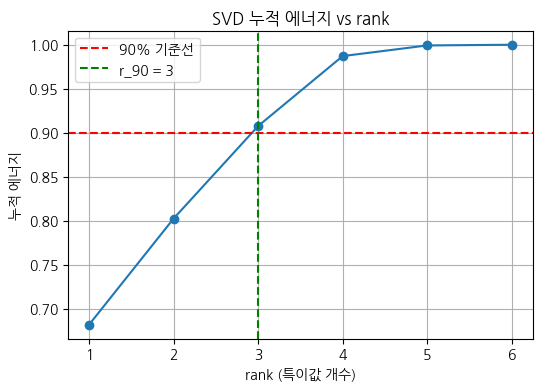

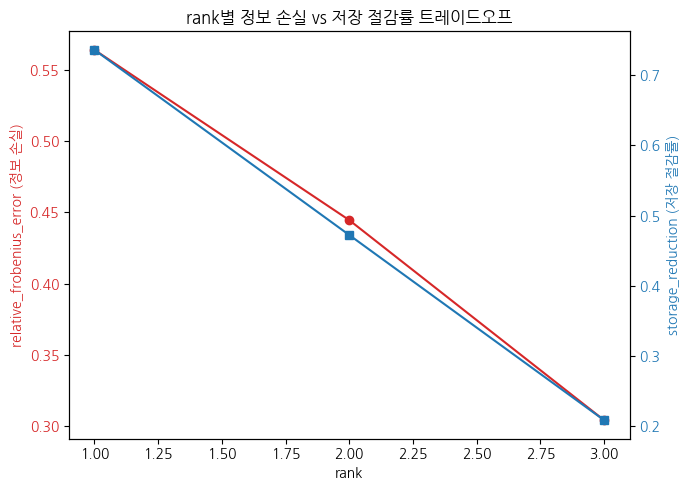

In [9]:
U, singular_values, Vt = np.linalg.svd(centered_embeddings, full_matrices=False)         # TODO
singular_energy_ratio = (singular_values ** 2) / np.sum(singular_values ** 2)     # TODO
cumulative_energy = np.cumsum(singular_energy_ratio)         # TODO
r_90_index = np.argmax(cumulative_energy >= 0.90)            # TODO
r_90 = r_90_index + 1

m, n = centered_embeddings.shape # TODO
original_storage = m * n

svd_reconstructions = {}            # 빈 딕셔너리 준비  # TODO
rows = []                           # 빈 리스트 준비

for r in [1, 2, 3]:
    Ur = U[:, :r]
    Sr = np.diag(singular_values[:r])
    Vtr = Vt[:r, :]

    A_r = Ur @ Sr @ Vtr                         # (12, 6) 근사 (중심화된 공간)
    svd_reconstructions[r] = A_r

    mse_r = np.mean((centered_embeddings - A_r) ** 2)
    rel_frob_error = np.linalg.norm(centered_embeddings - A_r) / np.linalg.norm(centered_embeddings)
    stored = m * r + r + r * n
    reduction = 1 - stored / original_storage

    rows.append({
        "rank": r,
        "retained_energy": cumulative_energy[r - 1],
        "mse": mse_r,
        "relative_frobenius_error": rel_frob_error,
        "stored_values": stored,
        "storage_reduction": reduction,
    })

svd_table = pd.DataFrame(rows)   # TODO
reconstructed_svd_r90 = svd_reconstructions[r_90] + embedding_mean          # TODO
svd_r90_mse = np.mean((document_embeddings - reconstructed_svd_r90) ** 2)   # TODO

if centered_embeddings is None:
    print("문제 2를 먼저 완성하세요.")
else:
    print("문제 3 TODO를 완성한 뒤 표와 그래프를 출력하세요.")


plt.figure(figsize=(6, 4))
plt.plot(range(1, 7), cumulative_energy, marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90% 기준선")
plt.axvline(r_90, color="green", linestyle="--", label=f"r_90 = {r_90}")
plt.xlabel("rank (특이값 개수)")
plt.ylabel("누적 에너지")
plt.title("SVD 누적 에너지 vs rank")
plt.legend()
plt.grid(True)
plt.show()


fig, ax1 = plt.subplots(figsize=(7, 5))

ax1.set_xlabel("rank")
ax1.set_ylabel("relative_frobenius_error (정보 손실)", color="tab:red")
ax1.plot(svd_table["rank"], svd_table["relative_frobenius_error"], marker="o", color="tab:red", label="상대 오차")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
ax2.set_ylabel("storage_reduction (저장 절감률)", color="tab:blue")
ax2.plot(svd_table["rank"], svd_table["storage_reduction"], marker="s", color="tab:blue", label="저장 절감률")
ax2.tick_params(axis="y", labelcolor="tab:blue")

plt.title("rank별 정보 손실 vs 저장 절감률 트레이드오프")
fig.tight_layout()
plt.show()

In [10]:
problem_3_values = {
    "U": U,
    "singular_values": singular_values,
    "Vt": Vt,
    "singular_energy_ratio": singular_energy_ratio,
    "cumulative_energy": cumulative_energy,
    "r_90": r_90,
    "original_storage": original_storage,
    "svd_table": svd_table,
    "svd_reconstructions": svd_reconstructions,
    "reconstructed_svd_r90": reconstructed_svd_r90,
    "svd_r90_mse": svd_r90_mse,
}

missing_problem_3 = [name for name, value in problem_3_values.items() if value is None]

if missing_problem_3:
    print("문제 3 미완성:", missing_problem_3)
else:
    assert U.shape == (12, 6), "U Shape을 확인하세요."
    assert singular_values.shape == (6,), "특이값 Shape을 확인하세요."
    assert Vt.shape == (6, 6), "Vt Shape을 확인하세요."
    assert np.all(np.diff(singular_values) <= 1e-12), "특이값 순서를 확인하세요."
    assert np.allclose(singular_energy_ratio.sum(), 1.0), "특이값 제곱 기반 에너지 비율을 확인하세요."
    assert 1 <= int(r_90) <= 6, "r_90 범위를 확인하세요."
    assert cumulative_energy[int(r_90) - 1] >= 0.90, "90% 에너지 기준을 확인하세요."
    if int(r_90) > 1:
        assert cumulative_energy[int(r_90) - 2] < 0.90, "최소 rank를 선택했는지 확인하세요."
    assert original_storage == 72, "원본 저장 원소 수 m*n을 확인하세요."
    assert reconstructed_svd_r90.shape == (12, 6), "SVD 복원 Shape을 확인하세요."
    assert np.allclose(svd_r90_mse, pca_reconstruction_mse), "같은 rank의 PCA·SVD 복원 관계를 확인하세요."
    expected_columns = ["rank", "retained_energy", "mse", "relative_frobenius_error", "stored_values", "storage_reduction"]
    assert list(svd_table.columns) == expected_columns, "SVD 비교표의 열을 확인하세요."
    assert np.all(np.diff(svd_table["retained_energy"]) > 0), "rank별 에너지가 증가해야 합니다."
    assert np.all(np.diff(svd_table["mse"]) < 0), "rank별 MSE가 감소해야 합니다."
    assert result_signature(singular_values) == "ac3b993576e14ee558a5c36f37c5b70498d8bcdfac55347c84747590754028f7", "Compact SVD 결과를 확인하세요."
    assert result_signature(svd_table[expected_columns].to_numpy()) == "d6ee23661d420d4dc2eb9afd86330f6d5902354bbaab10c718a7beb4515b2416", "rank별 복원·오차·저장량 계산을 확인하세요."
    assert result_signature([r_90, svd_r90_mse]) == "27e1d0e0250fb6cf9a8234abdf91aa055122017ec8e58f30ddacb36f432b7533", "r_90과 복원 MSE를 확인하세요."
    print("문제 3 자동 검증: PASS")


문제 3 자동 검증: PASS


### 문제 3 — SVD 압축 의사결정 메모

1. rank 증가에 따른 에너지와 오차 변화:
rank가 1→2→3으로 늘어날수록 retained_energy는 0.682→0.802→0.908로 증가했고, 반대로 mse는 0.0674→0.0419→0.0196, relative_frobenius_error는 0.564→0.445→0.304로 계속 감소했다. 즉 rank를 늘릴수록 더 많은 정보를 보존하면서 오차는 줄어드는 방향으로 움직였다.

2. 원본 저장 원소 수:
original_storage = 72 (12x6)

3. 추천 rank `r_90`:
r_90 = 3

4. 에너지 보존율:
cumulative_energy[2] = 0.9076(약 90.8%) — 90% 기준을 처음 충족하는 최소 rank

5. 저장 원소 수 / 저장 절감률:
rank 3 기준 stored_values = 57, storage_reduction = 0.2083 (약 20.8%) — 원본 72개 대비 57개만 저장

6. 재구성 MSE:
svd_r90_mse = 0.019578 (문제 2의 pca_reconstruction_mse와 동일)

7. 추천 이유와 한계:
rank 3은 저장팀이 요구한 두 조건(에너지 90% 이상, 원본보다 적은 저장량)을 모두 만족하는 최소 rank다. 하지만 rank 1(73.6% 절감)이나 rank 2(47.2% 절감)에 비해 rank 3의 절감률(20.8%)은 상대적으로 낮다. 따라서 90% 기준을 정확히 지켜야 한다면 rank 3이 적절하지만 저장 공간이 더 중요한 상황이라면 rank 2(80.2% 에너지, 47.2% 절감)도 대안으로 검토할 수 있다.


## 🚀 문제 3 선택 심화 M3 — 공식 점수에 영향 없음

같은 rank에서 직접 구현 PCA 복원과 SVD 복원이 거의 같은지 확인하세요.

In [11]:
RUN_M3_CHALLENGE = False

if RUN_M3_CHALLENGE:
    pca_vs_svd_max_abs_diff = None  # TODO: 두 복원 행렬의 최대 절대 차이
    reconstructions_match = None    # TODO: np.allclose(..., atol=1e-10)

    if pca_vs_svd_max_abs_diff is None or reconstructions_match is None:
        print("M3 미완성: 두 복원 결과를 비교하세요.")
    else:
        print("PCA-SVD 복원 최대 절대 차이:", pca_vs_svd_max_abs_diff)
        assert bool(reconstructions_match), "같은 rank의 PCA·SVD 복원 결과를 확인하세요."
        assert pca_vs_svd_max_abs_diff < 1e-10
        print("M3 도전 검증: PASS")
else:
    print("M3 도전: SKIPPED")


M3 도전: SKIPPED


# 문제 4. Causal Attention과 출력 Projection 학습 — 추가 종합 평가 5점

> 문제 4는 공식 구현 성취도 15점과 분리된 **6~7장 추가 종합 평가**입니다.

## 추가 종합 평가 기준

| 점수 | 기준 |
|---:|---|
| 5점 | Checkpoint A·B·C 정확히 구현, 모든 검증 통과, 누수·NLL·Gradient·Loss 변화를 근거로 정확히 해석 |
| 4점 | Attention·CE·Autograd 업데이트 구현과 핵심 검증 완료, 일부 해석 근거 부족 |
| 3점 | Attention·CE는 대체로 구현했으나 Autograd 업데이트 또는 검증이 불완전 |
| 2점 | 일부 계산은 수행했으나 Mask·Softmax 축·Shape·Gradient 중 주요 오류 존재 |
| 1점 | 코드 작성을 시작했으나 핵심 흐름이 구현되지 않음 |
| 0점 | 미제출 또는 전체 실행 불가 |

아래 고정 토큰 시퀀스로 Attention Forward와 다음 토큰 Cross Entropy를 계산합니다.

```text
<BOS> → 사내 → 비밀번호 → 재설정 → 방법
```

기본 문제에서는 Q/K/V Projection을 고정하고 출력 Projection `W_out`, `b_out`만 한 번 학습합니다. 문제를 한 번에 작성하지 말고 세 Checkpoint로 나누어 진행하세요.

| Checkpoint | 구현 범위 | 완료 조건 |
|---|---|---|
| A | Q/K/V → Context | Shape 정상, 행별 합 1, 미래 Weight 0 |
| B | Vocabulary Logits → CE | 확률 행별 합 1, 유한한 위치별 NLL |
| C | Autograd → SGD 1회 | Gradient Shape 정상, 업데이트 후 Loss 감소 |

> `F.cross_entropy`에는 Softmax 확률이 아니라 원본 logits를 전달해야 합니다.


In [12]:
vocabulary = ["<BOS>", "사내", "비밀번호", "재설정", "방법", "안내", "<EOS>"]
input_tokens = ["<BOS>", "사내", "비밀번호", "재설정", "방법"]

token_embeddings = np.array([
    [0.6, 0.1, 0.0, 0.2],
    [0.7, 0.2, 0.1, 0.1],
    [0.9, 0.0, 0.3, 0.2],
    [0.8, 0.1, 0.5, 0.4],
    [0.5, 0.3, 0.6, 0.7],
], dtype=np.float64)

W_Q = np.array([
    [ 0.5, -0.2,  0.3],
    [ 0.1,  0.4, -0.1],
    [ 0.3,  0.2,  0.5],
    [-0.2,  0.3,  0.4],
], dtype=np.float64)

W_K = np.array([
    [ 0.4,  0.1, -0.2],
    [-0.1,  0.5,  0.2],
    [ 0.2, -0.3,  0.6],
    [ 0.3,  0.2,  0.4],
], dtype=np.float64)

W_V = np.array([
    [ 0.3,  0.2,  0.4],
    [ 0.4, -0.1,  0.2],
    [-0.2,  0.5,  0.3],
    [ 0.1,  0.4, -0.3],
], dtype=np.float64)

initial_W_out = np.array([
    [ 0.2, -0.1,  0.3,  0.0, -0.2,  0.1,  0.05],
    [-0.3,  0.4, -0.1,  0.2,  0.1, -0.2,  0.30],
    [ 0.1,  0.0,  0.2, -0.2,  0.4,  0.3, -0.10],
], dtype=np.float64)

initial_b_out = np.array([0.0, 0.1, -0.05, 0.0, 0.05, -0.1, 0.0], dtype=np.float64)

# 각 위치에서 예측해야 하는 다음 토큰 index입니다.
targets = np.array([1, 2, 3, 4, 6], dtype=np.int64)

print("token_embeddings shape:", token_embeddings.shape)
print("W_Q/W_K/W_V shape:", W_Q.shape, W_K.shape, W_V.shape)
print("initial_W_out shape:", initial_W_out.shape)
print("targets:", targets)


token_embeddings shape: (5, 4)
W_Q/W_K/W_V shape: (4, 3) (4, 3) (4, 3)
initial_W_out shape: (3, 7)
targets: [1 2 3 4 6]


## Checkpoint A. Attention Forward

1. `Q`, `K`, `V`를 만들고 `QKᵀ / √d_k`를 계산하세요.
2. `j > i`인 미래 위치를 Boolean Causal Mask로 가리세요.
3. Mask를 **Softmax 전에** 적용하세요.
4. 마지막 축에서 안정 Softmax를 계산하세요.
5. `context = attention_weights @ V`를 만드세요.
6. 아래 검증 셀에서 `Checkpoint A: PASS`를 확인하세요.


In [13]:

def stable_softmax(values, axis=-1):
    """수치적으로 안정적인 Softmax를 완성하세요."""
    # TODO
    shifted = values - np.max(values, axis=axis, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / np.sum(exp_values, axis=axis, keepdims=True)


Q = token_embeddings @ W_Q                # TODO: token_embeddings @ W_Q
K = token_embeddings @ W_K                # TODO
V = token_embeddings @ W_V                # TODO
d_k = Q.shape[1]              # TODO
attention_scores = Q @ K.T / np.sqrt(d_k) # TODO: Q @ K.T / sqrt(d_k)
causal_mask = np.triu(np.ones_like(attention_scores, dtype=bool), k=1)     # TODO: j > i인 Boolean Mask
masked_scores = np.where(causal_mask, -np.inf, attention_scores)    # TODO
attention_weights = stable_softmax(masked_scores, axis=-1) # TODO
context = attention_weights @ V          # TODO

print("Checkpoint A TODO를 완성하세요.")


Checkpoint A TODO를 완성하세요.


In [14]:

checkpoint_a = {
    "Q": Q,
    "K": K,
    "V": V,
    "d_k": d_k,
    "attention_scores": attention_scores,
    "causal_mask": causal_mask,
    "masked_scores": masked_scores,
    "attention_weights": attention_weights,
    "context": context,
}
missing_a = [name for name, value in checkpoint_a.items() if value is None]

if missing_a:
    print("Checkpoint A 미완성:", missing_a)
else:
    assert Q.shape == K.shape == V.shape == (5, 3)
    assert int(d_k) == 3
    assert attention_scores.shape == causal_mask.shape == masked_scores.shape == (5, 5)
    assert causal_mask.dtype == bool
    assert attention_weights.shape == (5, 5)
    assert np.allclose(attention_weights.sum(axis=-1), 1.0)
    assert np.allclose(attention_weights[np.triu_indices(5, k=1)], 0.0, atol=1e-8)
    assert context.shape == (5, 3)
    assert result_signature(attention_weights) == "44b7fab0c5c307a628df153481124b6e3a252271159aae8fd61733d88d0f5b68"
    print("Checkpoint A: PASS")


Checkpoint A: PASS


## Checkpoint B. Vocabulary Softmax와 위치별 Loss

1. `context @ initial_W_out + initial_b_out`로 raw logits를 만드세요.
2. 마지막 축에서 Vocabulary Softmax를 계산하세요.
3. 각 위치의 정답 다음 토큰 확률과 NLL을 계산하세요.
4. 평균 NLL을 NumPy Cross Entropy로 저장하세요.
5. 가장 큰 NLL 위치를 확인하세요.
6. 검증 셀에서 `Checkpoint B: PASS`를 확인하세요.


In [20]:
initial_vocab_logits_np = context @ initial_W_out + initial_b_out  # TODO
initial_vocab_probs_np = stable_softmax(initial_vocab_logits_np, axis=-1)   # TODO
correct_token_probs = initial_vocab_probs_np[np.arange(len(targets)), targets]      # TODO
position_nll = -np.log(correct_token_probs)             # TODO
numpy_cross_entropy = np.mean(position_nll)      # TODO
worst_nll_position = np.argmax(position_nll)       # TODO

if context is None:
    print("Checkpoint A를 먼저 완성하세요.")
else:
    print("Checkpoint B TODO를 완성하세요.")


Checkpoint B TODO를 완성하세요.


In [21]:
checkpoint_b = {
    "initial_vocab_logits_np": initial_vocab_logits_np,
    "initial_vocab_probs_np": initial_vocab_probs_np,
    "correct_token_probs": correct_token_probs,
    "position_nll": position_nll,
    "numpy_cross_entropy": numpy_cross_entropy,
    "worst_nll_position": worst_nll_position,
}
missing_b = [name for name, value in checkpoint_b.items() if value is None]

if missing_b:
    print("Checkpoint B 미완성:", missing_b)
else:
    assert initial_vocab_logits_np.shape == initial_vocab_probs_np.shape == (5, 7)
    assert np.allclose(initial_vocab_probs_np.sum(axis=-1), 1.0)
    assert correct_token_probs.shape == position_nll.shape == (5,)
    assert np.isfinite(position_nll).all() and np.isfinite(numpy_cross_entropy)
    assert int(worst_nll_position) == int(np.argmax(position_nll))
    assert result_signature(initial_vocab_probs_np) == "488e23c3dcc0de21ef16a8bc79192798e7663b9bb5c9766bed65014e016980bc"
    print("Checkpoint B: PASS")


Checkpoint B: PASS


## Checkpoint C. PyTorch Autograd와 한 번의 SGD 업데이트

1. `context`, targets, `W_out`, `b_out`을 `torch.float64`로 준비하세요.
2. `W_out`, `b_out`만 `requires_grad=True`로 만드세요.
3. `torch.optim.SGD([W_out_t, b_out_t], lr=1.0)`을 사용하세요.
4. `zero_grad → forward → loss → backward → Gradient 복사 → step` 순서로 실행하세요.
5. `step()` 뒤에는 새 Forward로 Loss를 다시 계산하세요.
6. 검증 셀에서 `Checkpoint C: PASS`를 확인하세요.


In [17]:
context_t = torch.tensor(context, dtype=torch.float64)
targets_t = torch.tensor(targets, dtype=torch.long)
W_out_t = torch.tensor(initial_W_out, dtype=torch.float64, requires_grad=True)
b_out_t = torch.tensor(initial_b_out, dtype=torch.float64, requires_grad=True)

optimizer = torch.optim.SGD([W_out_t, b_out_t], lr=1.0)
optimizer.zero_grad()

initial_logits_t = context_t @ W_out_t + b_out_t
initial_loss_t = F.cross_entropy(initial_logits_t, targets_t)
initial_loss_t.backward()

grad_W_autograd = W_out_t.grad.detach().numpy().copy()
grad_b_autograd = b_out_t.grad.detach().numpy().copy()

with torch.no_grad():
    initial_probs_torch = F.softmax(initial_logits_t, dim=-1).numpy().copy()

initial_torch_loss = initial_loss_t.item()

optimizer.step()

with torch.no_grad():
    updated_logits_t = context_t @ W_out_t + b_out_t
    updated_loss_t = F.cross_entropy(updated_logits_t, targets_t)

updated_torch_loss = updated_loss_t.item()

if context is None or numpy_cross_entropy is None:
    print("Checkpoint A와 B를 먼저 완성하세요.")
else:
    print("Checkpoint C TODO를 완성하세요.")

Checkpoint C TODO를 완성하세요.


In [18]:

checkpoint_c = {
    "optimizer": optimizer,
    "grad_W_autograd": grad_W_autograd,
    "grad_b_autograd": grad_b_autograd,
    "initial_probs_torch": initial_probs_torch,
    "initial_torch_loss": initial_torch_loss,
    "updated_torch_loss": updated_torch_loss,
}
missing_c = [name for name, value in checkpoint_c.items() if value is None]

if missing_c:
    print("Checkpoint C 미완성:", missing_c)
else:
    assert np.allclose(numpy_cross_entropy, initial_torch_loss)
    assert grad_W_autograd.shape == (3, 7)
    assert grad_b_autograd.shape == (7,)
    assert updated_torch_loss < initial_torch_loss
    assert result_signature([numpy_cross_entropy, initial_torch_loss, updated_torch_loss]) == "b8368a6bdafae26a087cdeec0d49cbf1c9e5e0278c47a63c6b7d7a0671b9a5b7"
    assert result_signature(grad_W_autograd) == "4c50d7b9a7ead967ffe8ebe1bb6f9c07ffc496b7223a5128c61438ed55e741b5"
    assert result_signature(grad_b_autograd) == "26944bff87ae878f1f2a34240dc8ba6188226caeaca124397cf1286681462e64"
    print("Checkpoint C: PASS")


Checkpoint C: PASS


### 문제 4 — Attention·학습 진단 보고

1. Attention Score 행과 열의 의미:
attention_scores[i, j]는 i번째 토큰의 쿼리와 j번째 토큰의 키 사이의 유사도를 √d_k로 스케일링한 값이다. 즉 행(i)은 "지금 정보를 찾고 있는 토큰", 열(j)은 "그 토큰이 얼마나 주목할 만한지 평가받는 대상 토큰"을 의미하며, 이 값이 클수록 i번째 토큰이 j번째 토큰에 강하게 주목한다.

2. Causal Mask를 Softmax 전에 적용하는 이유:
Softmax는 입력값에 지수함수를 취하는데, -inf를 넣으면 (-inf)=0이 되어 해당 위치의 확률이 정확히 0이 되면서도 나머지 값들의 Softmax 정규화(행별 합=1)는 그대로 정상적으로 유지된다. 반대로 Softmax를 먼저 계산한 뒤 미래 위치를 0으로 바꿔버리면 그 행의 확률 합이 1보다 작아져 더 이상 올바른 확률 분포가 아니게 된다.

3. 미래 토큰 누수 여부 / 행별 합:
attention_weights의 미래 위치, j>i 값은 전부 0으로 확인되어 미래 토큰 정보 누수가 없음을 검증했다. 또한 attention_weights.sum(axis=-1)이 모든 행에서 1.0으로 나와, 각 위치가 과거 및 자기 자신 토큰에 대해서만 올바른 확률 분포를 형성함을 확인했다.

4. 가장 큰 NLL 위치와 토큰:
worst_nll_position = 2, "비밀번호" 토큰 위치에서 다음 토큰 "재설정"을 예측하는 것에 대한 확신도가 가장 낮았다.(NLL이 가장 큼)

5. NumPy CE / PyTorch 초기 Loss:
numpy_cross_entropy = [본인 노트북에서 나온 값 확인 후 기입], initial_torch_loss = 1.9096416144216348 — 두 값이 동일하여, NumPy로 수동 계산한 Cross Entropy와 PyTorch F.cross_entropy의 계산 결과가 일치함을 확인했다.

6. 업데이트 전 Loss / 업데이트 후 Loss:
업데이트 전 1.9096416144216348 → 업데이트 후
1.853165050440118로 감소했다.

7. `backward()`와 `step()`의 역할 차이:
backward()는 현재 loss로부터 계산 그래프를 거슬러 올라가며 각 파라미터(W_out, b_out)에 대한 gradient를 계산만 하여 grad에 저장하는 단계지만 step()은 그 gradient를 실제로 사용해 파라미터 값을 직접 갱신하는 단계다.

8. Gradient 계산과 업데이트가 정상이라고 판단한 근거:
grad_W_autograd.shape이 (3,7), grad_b_autograd.shape이 (7,)로 각각 W_out, b_out과 동일한 shape을 가져 gradient가 각 파라미터의 모든 원소에 대해 올바르게 계산되었음을 확인했다. step() 이후 동일한 입력(context_t)에 대해 다시 계산한 loss(1.8532)가 업데이트 전 loss(1.9096)보다 감소했다는 점을 보아 gradient의 방향과 크기가 실제로 loss를 줄이는 방향으로 계산되었다는것을 알 수 있다.

## 🚀 문제 4 선택 심화 M4 — 추가 종합 점수에 영향 없음

Autograd가 계산한 출력 Projection Gradient를 NumPy로 직접 계산해 비교하세요.

```text
dLogits = (P - Y_one_hot) / N
dW_out = contextᵀ @ dLogits
db_out = sum(dLogits, axis=0)
```

In [19]:
RUN_M4_CHALLENGE = False

if RUN_M4_CHALLENGE:
    one_hot_targets = None  # TODO
    dlogits_manual = None   # TODO: (P - Y_one_hot) / N
    dW_out_manual = None    # TODO: context.T @ dlogits_manual
    db_out_manual = None    # TODO: dlogits_manual.sum(axis=0)

    challenge_values = {
        "one_hot_targets": one_hot_targets,
        "dlogits_manual": dlogits_manual,
        "dW_out_manual": dW_out_manual,
        "db_out_manual": db_out_manual,
    }
    missing = [name for name, value in challenge_values.items() if value is None]
    if missing:
        print("M4 미완성:", missing)
    else:
        assert np.allclose(dW_out_manual, grad_W_autograd, atol=1e-12), "수동 dW와 Autograd를 비교하세요."
        assert np.allclose(db_out_manual, grad_b_autograd, atol=1e-12), "수동 db와 Autograd를 비교하세요."
        print("M4 도전 검증: PASS")
else:
    print("M4 도전: SKIPPED")


M4 도전: SKIPPED


# 🧾 최종 엔지니어링 요약 보고서

아래 항목을 실제 실행 결과로 완성하세요. 숫자·문서명·Shape을 근거로 작성하세요.

## 1. 문서 검색
- Query: "비밀번호를 잊었을 때 계정을 다시 사용하는 방법"
- Cosine Top-3: ① 계정 잠금 해제 가이드 (0.9995) ② 비밀번호 재설정 절차 (0.9980) ③ VPN 접속 오류 해결 (0.9755)
- 검색 결과 평가: 쿼리 특징 벡터에서 보안·접근(1.00), 절차(1.00), 계정·요청(0.95)이 강하게 설정되어 있었고, Top-3 문서 모두 해당 성격이 강한 문서로 정확히 일치한다. 정규화 전 크기가 유난히 큰 8번 문서("GCP GPU VM 생성")는 Top-3에 전혀 포함되지 않아, Cosine Similarity가 벡터 크기(norm)에 왜곡되지 않고 순수하게 방향(의미) 기반으로 검색되었음을 확인했다.

## 2. PCA 차원 축소
- 추천 차원 `k`: 3 (원래 6차원 → 3차원)
- 누적 설명분산: 0.9076 (약 90.8%, `cumulative_ratio[2]`)
- 재구성 MSE: 0.019578

## 3. SVD 압축
- 추천 rank `r`: 3
- 에너지 보존율: 0.9076 (약 90.8%, `cumulative_energy[2]`)
- 저장 절감률: 20.8% (원본 72개 → 압축 57개, `stored_values=57`)
- 재구성 MSE: 0.019578 (같은 데이터의 같은 분산 구조를 다른 경로로 계산했기 때문에 PCA와 사실상 동일)

## 4. Attention 및 다음 토큰 예측
- 미래 토큰 누수 여부: 없음 — `attention_weights`의 미래 위치(j>i) 값이 전부 0으로 확인, 행별 합(sum(axis=-1))은 모두 1.0으로 정상적인 확률 분포 유지
- 평균 Cross Entropy: 1.9096416144216348 (PyTorch 초기 Loss 1.9096416144216348과 일치)
- 가장 큰 NLL 위치: 위치 2 (비밀번호 → 재설정을 예측하는 자리에서 확신도가 가장 낮음)

## 5. 학습 업데이트
- 업데이트 전 Loss: 1.9096416144216348
- 업데이트 후 Loss: 1.853165050440118
- 감소 여부: 감소함 (약 0.0565 감소, `backward()`로 계산한 Gradient(`W_out`: (3,7), `b_out`: (7,))를 `step()`으로 1회 반영한 결과)

## 6. 최종 결론
- 이번 PoC에서 확인한 핵심 수학 원리: (1) 벡터를 정규화하면 크기가 아니라 방향(의미)으로 비교할 수 있어 검색 품질이 좋아진다는 점, (2) PCA와 SVD는 계산 방법은 다르지만 결국 같은 결과(같은 분산 구조)를 찾아낸다는 점, (3) 차원이나 rank를 줄일수록 저장 공간은 아낄 수 있지만 정보 손실은 커지는 트레이드오프가 항상 있다는 점, (4) Causal Mask는 Softmax를 적용하기 전에 걸어야 확률 합이 정확히 1로 유지된다는 점, (5) Gradient 계산(backward)과 실제 값 업데이트(step)는 분리된 단계이고 이 둘이 합쳐져야 Loss가 실제로 줄어든다는 점.

- 운영 전에 추가로 검증해야 할 항목: (1) 문서가 수천~수만 건으로 많아져도 지금과 비슷한 수준으로 검색이 잘 되고 압축 손실도 적은지, (2) 애매하거나 복잡한 질문에도 검색이 잘 맞는지, (3) Q/K/V까지 전부 학습시킬 때도 안정적으로 학습이 잘 되는지, (4) 실제 서비스에서 응답 속도와 저장 비용이 감당할 만한 수준인지.


# 최종 제출 체크

- [ ] 공식 성취도 문제 1~3 자동 검증이 모두 `PASS`입니다.
- [ ] 추가 종합 평가 문제 4 Checkpoint A·B·C가 모두 `PASS`입니다.
- [ ] 그래프와 표가 출력된 상태입니다.
- [ ] 문제별 해석과 의사결정 메모를 실제 결과로 작성했습니다.
- [ ] 최종 엔지니어링 요약 보고서를 작성했습니다.
- [ ] 선택 심화는 점수 필수 조건이 아니며, 수행하지 않았다면 flag가 `False`입니다.
- [ ] 새 런타임에서 `모두 실행`이 완료됩니다.

---

Copyright ⓒ TeamSparta All rights reserved.


# 📝 기초수학 과제 — AI를 활용한 부분(질문 및 코드 이해를 위해)

## 💡 개념

| 개념 | 한 줄 정리 |
|---|---|
| 브로드캐스팅 | shape이 다른 배열끼리 연산할 때, 작은 쪽이 자동으로 복제되어 맞춰짐 |
| L2 정규화 | 벡터 크기를 1로 맞춰서 "크기"가 아닌 "방향(의미)"만 비교하게 만듦 |
| 쿼리 vs 문서 임베딩 차원 | 쿼리는 1개(1차원), 문서는 여러 개 쌓임(2차원) — 입력 차원이 그대로 유지됨 |
| PCA | 평균 중심화 → 공분산 행렬 → 고유값 분해로 "가장 중요한 방향" 찾기 |
| SVD | 행렬을 U·Σ·Vᵀ로 쪼개서 중요한 조각만 남기고 압축 (고유값 = 특이값²) |
| PCA ≒ SVD | 계산 경로는 다르지만 같은 데이터의 같은 분산 구조를 찾으므로 결과(k=3, r=3)가 같음 |
| Causal Mask 적용 시점 | Softmax **전에** `-inf`로 가려야 확률 합이 정확히 1로 유지됨 |
| `np.triu(k=1)` vs `k=0` | `k=1`은 대각선 제외(자기 자신은 봄), `k=0`은 대각선 포함(자기 자신도 못 봄 → 오류) |
| NLL / Cross Entropy | 정답 확률에 `-log`를 씌운 것(NLL), 여러 위치의 NLL 평균이 Cross Entropy |
| `backward()` vs `step()` | backward = gradient **계산만**, step = 그 값으로 파라미터 **실제 갱신** |
| Attention Score의 행/열 의미 | 행(i)은 질문하는 토큰, 열(j)은 평가받는 토큰 — Q·K 유사도를 나타냄 |
| √d_k로 나누는 이유 | 차원이 커질수록 내적 값이 자연히 커지는 걸 방지해 Softmax가 한쪽으로 쏠리지 않게 함 |
| Stable Softmax (수치 안정화) | 각 값에서 그 행의 **최댓값을 먼저 뺀 뒤** `exp`를 씌우고 합으로 나눔 — 큰 수로 인한 overflow(무한대 발산) 방지, 수학적으로 원래 Softmax와 결과는 완전히 동일 |

## 🔧 함수·문법

| 함수/문법 | 설명 |
|---|---|
| `np.linalg.norm(x, axis=1, keepdims=True)` | 축별로 norm 계산, keepdims로 브로드캐스팅 가능하게 유지 |
| `np.argsort(x)[::-1]` | 내림차순 정렬 인덱스 얻기 |
| `eigenvalues, eigenvectors = np.linalg.eigh(A)` | 튜플 unpacking을 한 줄에 해야 함 (두 줄로 나눠 쓰면 둘 다 튜플 전체가 들어감) |
| `eigenvectors[:, order]` | 열(각 고유벡터) 순서만 재배치 |
| `np.argmax(조건배열)` | 조건을 처음 만족하는 위치 찾기 (True=1이 처음 나오는 index) |
| `np.cumsum(x)` | 누적합 |
| `np.diag(v)` | 벡터를 대각행렬로 변환 |
| `np.ones_like(A)` | A와 같은 shape으로 채우기 |
| `배열[np.arange(n), targets]` | 행마다 다른 열 값을 한 번에 뽑는 인덱싱 |
| `np.linalg.svd(A, full_matrices=False)` | Compact SVD, 불필요하게 큰 U 방지 |
| `np.triu(..., k=1)` | 대각선 제외한 상삼각 부분만 True로 |
| `torch.tensor(x, requires_grad=True)` | 학습 대상 지정 |
| `optimizer.zero_grad()` / `.backward()` / `.step()` | gradient 초기화 → 계산 → 실제 갱신 3단계 |
| `.detach().numpy()` | 계산 그래프에서 분리 후 넘파이로 안전하게 변환 |
| `F.cross_entropy(logits, targets)` | Softmax 전 raw logits를 넣어야 함 (직접 softmax 적용 금지) |

## 🛠️ 그래프 구현 / 기타

 **한글 폰트 깨짐 (Colab)**:
- matplotlib 그래프에 한글이 네모(□)로 깨져서 나옴 → 나눔고딕 폰트 설치 후 `plt.rc("font", family="NanumGothic")` 설정으로 해결
- **matplotlib 그래프 구현**: 그래프를 그리는 코드 자체는 전혀 몰라서 AI 도움을 받아 작성함
- **PCA/SVD 그래프**: 누적 설명분산/에너지 그래프, PC1-PC2 산점도, 압축률-손실 트레이드오프 그래프(이중 y축) 등도 AI 도움으로 구현

 **자주 발생한 코드 실수**:
- 함수 안에서 매개변수 대신 바깥 변수 이름을 직접 참조 (`l2_normalize_rows` 안에서 `document_embeddings`를 그대로 씀 → 재사용 불가능한 함수가 됨)
- `np.linalg.eigh(...)`를 두 줄로 나눠 호출해서 `eigenvalues`, `eigenvectors` 둘 다 튜플 전체가 담김 (한 줄에 unpacking 필요)
- `np.triu(..., k=1)`에서 `k=1`을 빠뜨려 대각선(자기 자신)까지 마스킹해버림
- `np.rgmax` 같은 오타(`argmax`가 맞음), 괄호 개수 불일치
- 기준값 단위 실수 (`>= 90` vs `>= 0.90` — 비율은 0~1 사이인데 퍼센트처럼 씀)
- 딕셔너리 안 콤마 누락 등 문법 실수